# Proyecto Series Temporales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Cargamos los datos
df_train = pd.read_parquet("ts-train.parquet")
df_test = pd.read_parquet("ts-test.parquet")

In [3]:
df_train.head()

,mw,temp,hora,dia,diasemana,mes,anyo
fecha,,,,,,,
2017-02-01 00:53:00,1419.881,37.0,0,1,2,2,2017
2017-02-01 01:53:00,1379.505,37.0,1,1,2,2,2017
2017-02-01 02:53:00,1366.106,36.0,2,1,2,2,2017
2017-02-01 03:53:00,1364.453,36.0,3,1,2,2,2017
2017-02-01 04:53:00,1391.265,36.0,4,1,2,2,2017


## 5. Visualizando los datos

Comenzamos pintando el consumo de energía a lo largo del tiempo

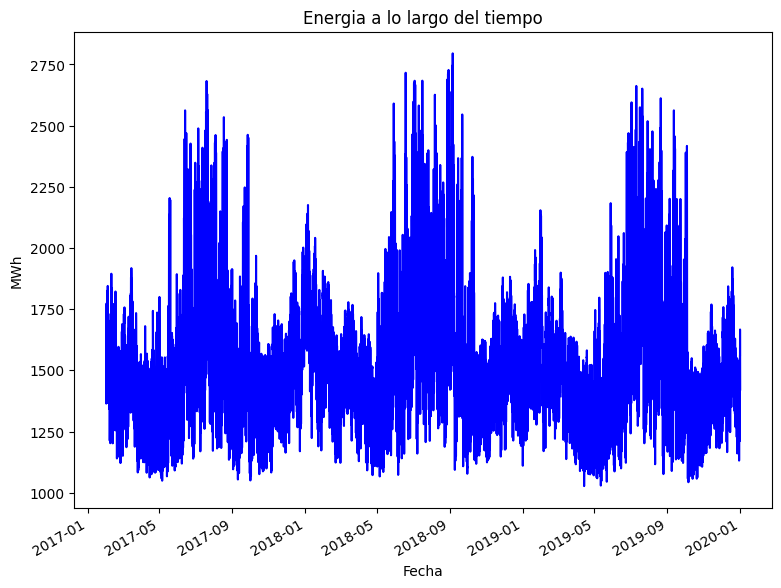

In [ ]:
ax1 = df_train['mw'].plot(color = 'blue', figsize=(9,7))

ax1.set_ylabel('MWh')
ax1.set_xlabel('Fecha')
ax1.set_title('Energía a lo largo del tiempo')

plt.show()

Parece que tenemos algunos patrones interesantes en el gráfico. Parece que el consumo de energía se mueve cíclicamente a lo largo del año. En primavera y otoño se observa un descenso del consumo. Esto se debe probablemente a que las temperaturas suaves facilitan (o incluso hacen innecesario) calentar y enfriar los edificios. En los meses de invierno se producen algunos picos, ya que es necesario calentar los edificios. Sin embargo, con una gran variedad de métodos de calefacción, puede que en algunos edificios no sea necesaria la electricidad para calentarlos. Los mayores picos aparecen en los meses de verano. No es de extrañar. La forma más habitual de refrigerar un edificio es utilizar electricidad para ello a través de sistemas de aire acondicionado.

Vamos a centrarnos en un período de tiempo más corto para ver si podemos identificar patrones adicionales. Nos centraremos en una semana de diciembre del año 2019.

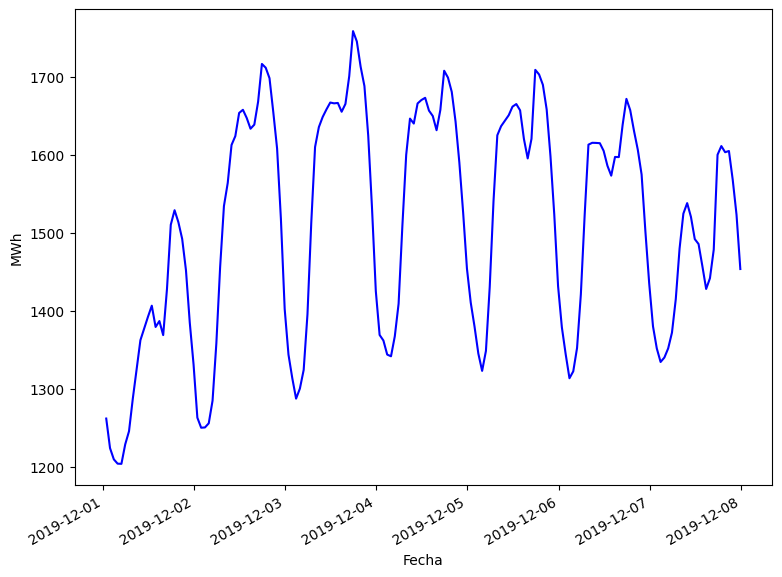

In [7]:
train_mw = df_train['mw']

ax1 = train_mw['2019-12-01':'2019-12-07'].plot(color = 'blue', figsize=(9,7))

ax1.set_ylabel('MWh')
ax1.set_xlabel('Fecha')

plt.show()

En el gráfico anterior tenemos de domingo a sábado. Podemos ver fácilmente que los domingos y los sábados tienen un consumo de energía drásticamente inferior al del resto de la semana. Esto no es demasiado sorprendente, ya que la mayoría de las grandes empresas cierran los fines de semana y no necesitan controlar la temperatura de sus edificios ni tener las luces encendidas.

La temperatura exterior es un factor determinante del consumo de energía. Examinemos los mismos periodos de tiempo para la temperatura que para la energía.

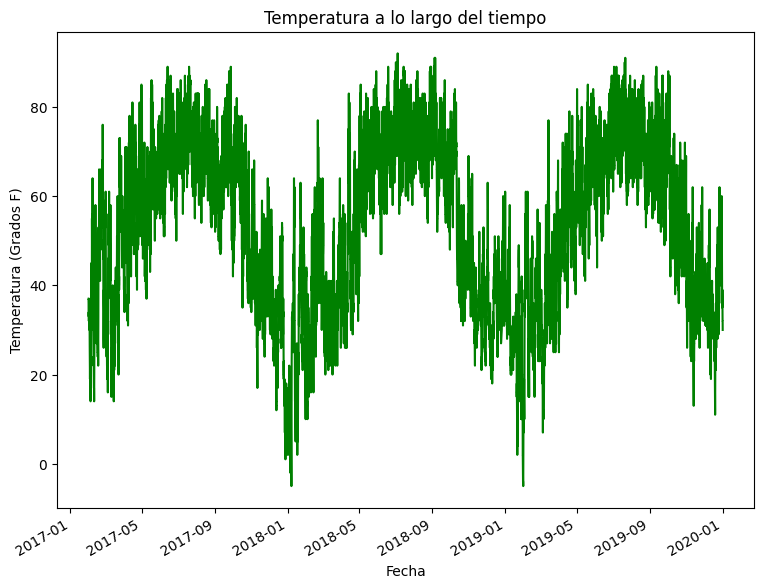

In [9]:
ax2 = df_train['temp'].plot(color = 'green', figsize=(9,7))

ax2.set_ylabel('Temperatura (Grados F)')
ax2.set_xlabel('Fecha')
ax2.set_title('Temperatura a lo largo del tiempo')

plt.show()

Vemos que la temperatura tiene un patrón general diferente al del uso de la energía. No es sorprendente que los meses de invierno sean los más fríos y los de verano los más calurosos. A partir de este gráfico, podría parecer que no podemos utilizar la temperatura para predecir la energía, ya que los patrones son diferentes. Vamos a superponerlos en el mismo gráfico para ver si eso ayuda a mostrar alguna posible relación.

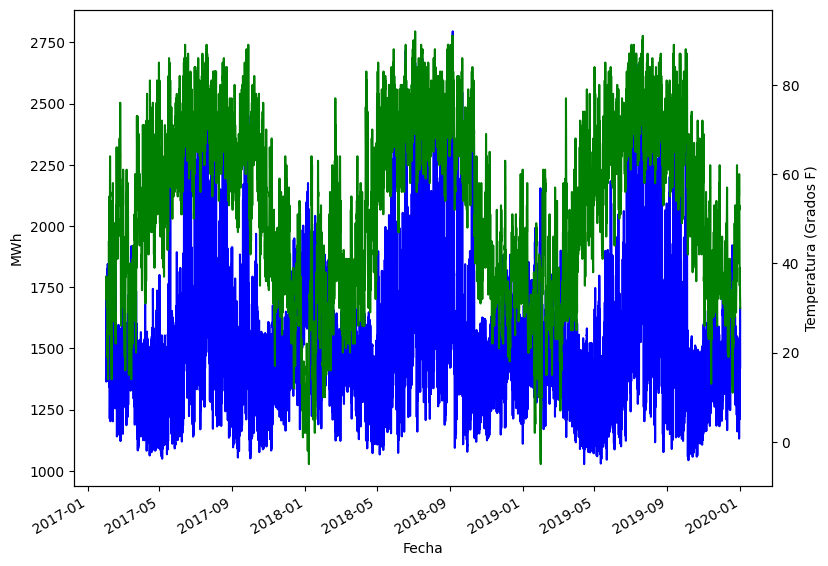

In [11]:
ax1 = df_train['mw'].plot(color = 'blue', figsize=(9,7))

ax1.set_ylabel('MWh')
ax1.set_xlabel('Fecha')

ax2 = ax1.twinx()

ax2 = df_train['temp'].plot(color = 'green', figsize=(9,7), ax=ax2)

ax2.set_ylabel('Temperatura (Grados F)')

plt.show()

Ahora podemos empezar a ver la relación que esperábamos. Cuando la temperatura es **muy fría** o muy cálida (invierno o verano), se consume más energía. Cuando la temperatura exterior es más suave (primavera u otoño), se consume menos energía. Así que parece que la temperatura y la energía **tienen** una relación. Pero potencialmente complicada. Recordémoslo para nuestros modelos.

Centrémonos ahora en una semana de temperatura y energía. Sin embargo, examinemos tanto una semana en invierno como una semana en verano.

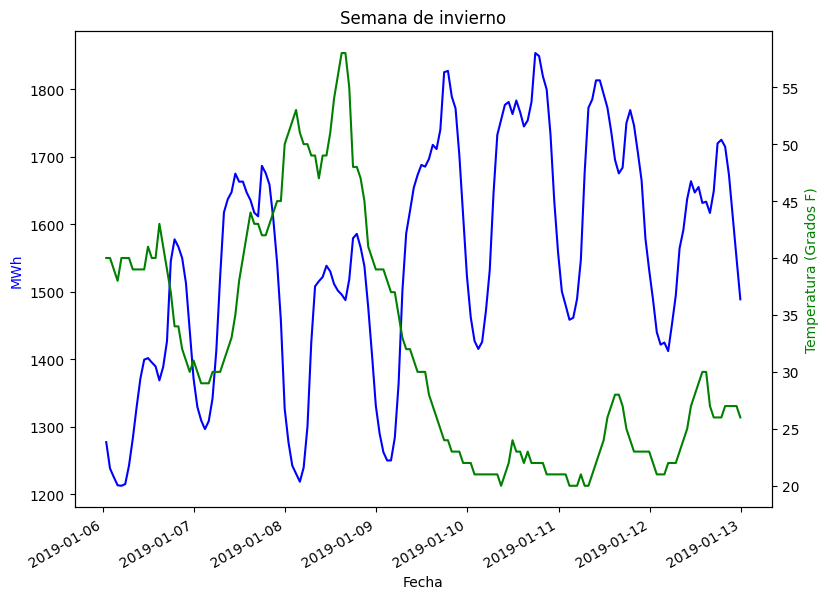

In [ ]:
train_mw = df_train['mw']
train_t = df_train['temp']

ax1 = train_mw['2019-01-06':'2019-01-12'].plot(color = 'blue', figsize=(9,7))

ax1.set_ylabel('MWh', color='blue')
ax1.set_xlabel('Fecha')

ax2 = ax1.twinx()

ax2 = train_t['2019-01-06':'2019-01-12'].plot(color = 'green', figsize=(9,7))

ax2.set_ylabel('Temperatura (Grados F)', color='green')

ax2.set_title('Semana de invierno')
plt.show()

La relación entre temperatura y energía es la que cabría esperar de este gráfico de una semana de enero. Cuando la temperatura subió durante uno o dos días, el consumo de energía fue menor, ya que no hacía falta calentar tanto los edificios. Sin embargo, cuando la temperatura descendió hacia el final de la semana, los niveles de energía aumentaron. 

Veamos ahora una semana de verano.

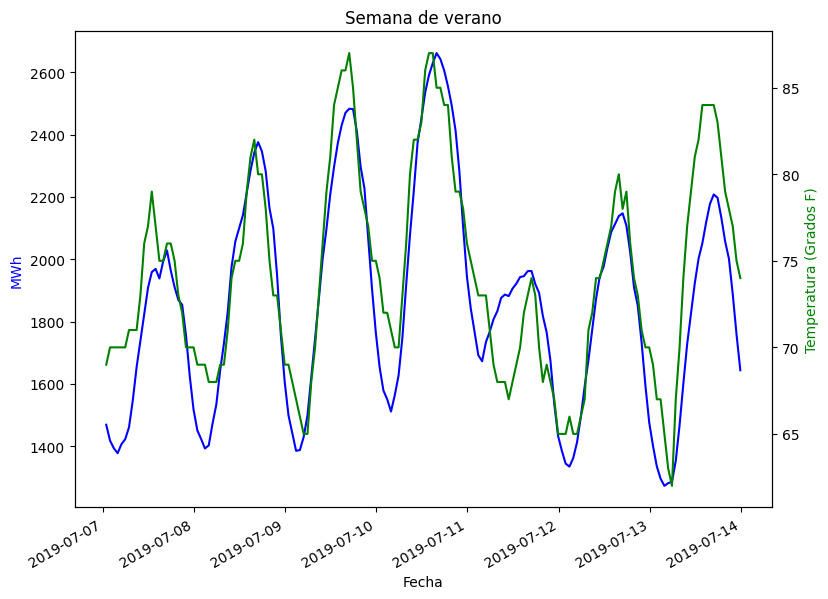

In [17]:
train_mw = df_train['mw']
train_t = df_train['temp']

ax1 = train_mw['2019-07-07':'2019-07-13'].plot(color = 'blue', figsize=(9,7))

ax1.set_ylabel('MWh', color='blue')
ax1.set_xlabel('Fecha')

ax2 = ax1.twinx()

ax2 = train_t['2019-07-07':'2019-07-13'].plot(color = 'green', figsize=(9,7))

ax2.set_ylabel('Temperatura (Grados F)', color='green')

ax2.set_title('Semana de verano')
plt.show()

¡Vaya! Estas líneas están casi superpuestas. Parece que, en verano, el consumo de energía sigue muy de cerca a la temperatura. A medida que aumenta la temperatura, también lo hace el consumo de energía. A medida que baja la temperatura, también lo hace el consumo de energía.


### Correlación


Una medida de la fuerza de una relación entre variables es la correlación. Podemos calcular fácilmente la correlación entre la temperatura y la energía utilizando la función `corr` en nuestro dataframe.



In [18]:
correlation = df_train['temp'].corr(df_train['mw'])
print("La correlación es: ", correlation)

La correlación es:  0.32753955690741215


Tal vez pensabas que el número de correlación (delimitado entre -1 y 1, siendo 0 la ausencia de relación) sería mayor en magnitud. Recuerde que la correlación es una medida de relación *lineal*. Aunque la temperatura y la energía se mueven juntas en verano, se mueven a la inversa en invierno. Si sólo observáramos la correlación en esas estaciones, sería mucho mayor. Pero tienen efectos opuestos, lo que hace que la correlación parezca un poco más débil.


### Gráfico de dispersión

De los gráficos anteriores se desprende que algo ocurre entre la temperatura y el consumo de energía. Vamos a crear un gráfico de dispersión entre la temperatura (eje x) y el consumo de energía (eje y).

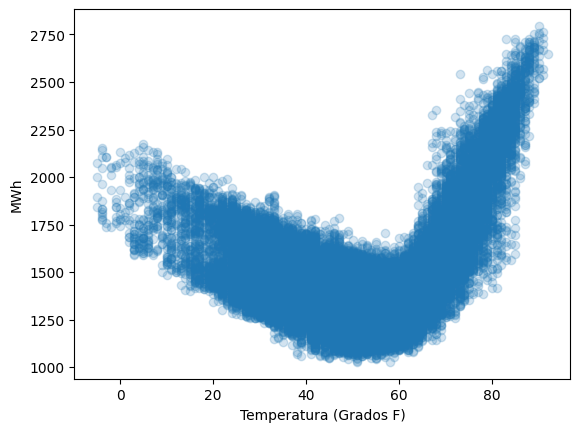

In [19]:
plt.scatter(df_train['temp'], df_train['mw'], alpha = 0.2)
plt.xlabel('Temperatura (Grados F)')
plt.ylabel('MWh')
plt.show()

Perfecto. La energía y la temperatura tienen una relación, aunque un poco complicada. Probablemente se podría decir que es de naturaleza cuadrática. La parte interesante es donde la relación parece cambiar. Parece que por debajo de 60 grados Fahrenheit cuando la temperatura baja, la energía sube. Sin embargo, por encima de 60 grados Fahrenheit, a medida que aumenta la temperatura, también lo hace el consumo de energía.

Entender la complicada relación entre estas dos variables a través de visualizaciones ayuda a entender el primer modelo energético y la previsión que construiremos a continuación. Sin esta comprensión, nuestros modelos no serán todo lo precisos que podrían ser.

> Recuerda que la precisión es clave en este sector. Tienes que entregar un modelo preciso a tu jefe. No querrás un modelo que sólo funcione en algunas estaciones del año

MIO: Generamos una línea de tendencia sobre el gráfico de dispersión para ver si la relación es lineal o no. Parece que no lo es, ya que la línea de tendencia no es recta.

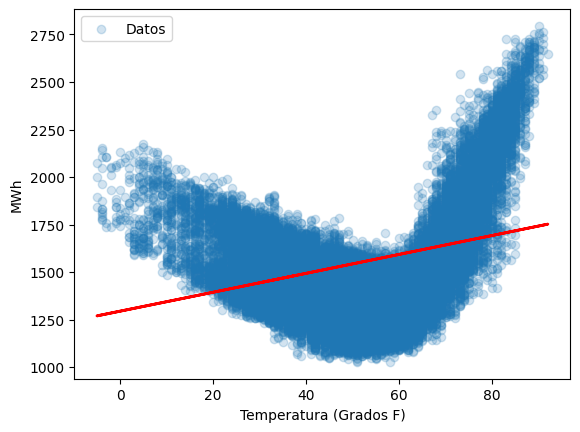

In [24]:
plt.scatter(df_train['temp'], df_train['mw'], alpha=0.2, label='Datos')

# Ajuste cuadrático
m, b = np.polyfit(df_train['temp'], df_train['mw'], 1)
plt.plot(df_train['temp'], m*df_train['temp'] + b, color='red', linewidth=2)

plt.xlabel('Temperatura (Grados F)')
plt.ylabel('MWh')
plt.legend()
plt.show()